# Lab Instructions

You are working as an analyst for a consulting agency that has been hired to study and improve productivity at a mid-sized company.  Morale is very low and, after speaking with employees, several common complaints kept coming up:

* New employees complained that more tenured employees were lazy and unproductive.
* More tenured employees complained that the newer employees didn't focus and were therefore unproductive.
* Managers were worried that remote workers might be less productive.
* In-person employees found it impossible to focus and be productive when their desk was in the open plan area.
* Many people said they had so much administrative work to do they could only be truly productive if they worked overtime.
* Everyone complained that there were too many meetings.

The consulting agency carefully collected data on a number of factors including number of years at the company, focus (higher is better), productivity (higher is better), department, meetings per week, and desk location can be found in Employee_productivity.csv.

1. Determine which feature - years at the company, hours worked, or focus - has the strongest linear relationship with productivity.  Show a visualization and calculate R-squared for all three relationships to justify your answer.

2. Build on that linear regression model to determine what other featuers also impact productivity. Using both visualzations and R-squared values, build a model that can predicts employee productivity at this company. Evaluate each feature in the dataset.

3. Write a short (a few sentences) summary of how the different factors in the data relate to employee productivity.  What recommendations would you make so that employees can be as productive as possible?

**For the purposes of this lab you MUST use the model building techniques we covered in class.  Failure to do so will automatically result in a 20 point deduction.  I really want you to think about what you are doing and not just paste what you get from ChatGPT (which will often NOT do the correct thing by default).**



In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [3]:
df_productivity = pd.read_csv("Employee_productivity.csv")
df_productivity.head()

,HoursWorked,FocusScore,ProductivityScore,Department,YearsAtCompany,TeamMeetingsPerWeek,DeskLocation
0,42.4,6.3,3127.96,Engineering,17,0,Open Plan
1,34.0,7.2,4742.60,HR,8,6,Private Office
2,47.2,5.6,2044.73,Sales,15,3,Remote
3,38.4,9.0,5818.92,HR,5,6,Private Office
4,36.4,2.5,1841.31,Sales,9,6,Remote


### RELATIONSHIP BETWEEN YEAR AT COMPANY WITH PRODUCTIVITY

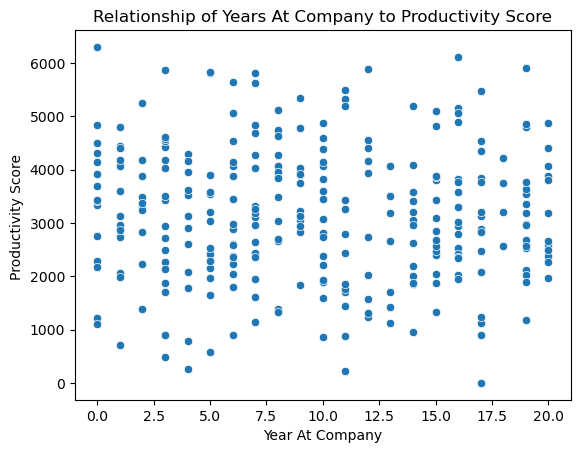

In [10]:
sns.scatterplot(data = df_productivity, x = 'YearsAtCompany', y = 'ProductivityScore')
plt.title("Relationship of Years At Company to Productivity Score")
plt.ylabel("Productivity Score ")
plt.xlabel("Year At Company")
plt.show()

In [12]:
X = sm.add_constant(df_productivity['YearsAtCompany'])
y = df_productivity['ProductivityScore']
year_model = sm.OLS(y,X).fit()
year_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      ProductivityScore   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                    0.1227
Date:                Mon, 18 May 2026   Prob (F-statistic):              0.726
Time:                        13:43:26   Log-Likelihood:                -2564.1
No. Observations:                 300   AIC:                             5132.
Df Residuals:                     298   BIC:                             5140.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           3154.6734    136.338     23.139      0.000    2886.366    3422.981
YearsAtCompany    -4.2493     12.132     -0.350      0.726     -28.124      19.625
==============================================================================
Omnibus:                        2.338   Durbin-Watson:                   1.945
Prob(Omnibus):                  0.311   Jarque-Bera (JB):                2.025
Skew:                           0.091   Prob(JB):                        0.363
Kurtosis:                       2.641   Cond. No.                         21.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

From the scatterplot it's obvious that the number of years at the company and the productivity score don't have any linear relationship at all. Looking at the R-squared we are given a negative score which means that the linear relationship bewtween years and productivity is very bad.

### RELATIONSHIP BETWEEN PRODUCTIVITY SCORE WITH WORK-HOURS

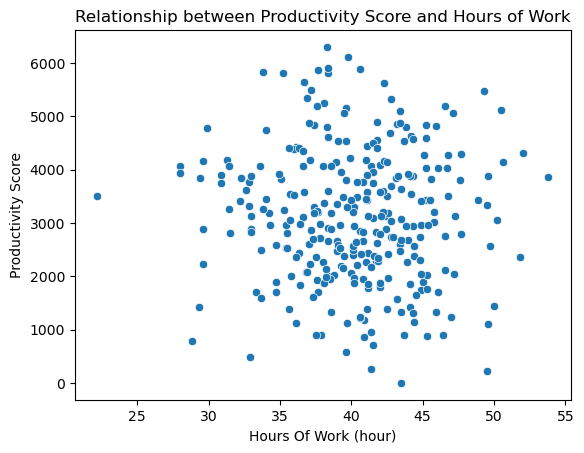

In [17]:
sns.scatterplot(data = df_productivity, x = 'HoursWorked', y = 'ProductivityScore')
plt.title("Relationship between Productivity Score and Hours of Work")
plt.xlabel("Hours Of Work (hour)")
plt.ylabel("Productivity Score")
plt.show()

In [18]:
X = sm.add_constant(df_productivity['HoursWorked'])
y = df_productivity['ProductivityScore']
hour_model = sm.OLS(y,X).fit()
hour_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      ProductivityScore   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.7768
Date:                Mon, 18 May 2026   Prob (F-statistic):              0.379
Time:                        14:01:59   Log-Likelihood:                -2563.7
No. Observations:                 300   AIC:                             5131.
Df Residuals:                     298   BIC:                             5139.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        3638.4153    599.175      6.072      0.000    2459.265    4817.566
HoursWorked   -13.0329     14.787     -0.881      0.379     -42.133      16.068
==============================================================================
Omnibus:                        2.775   Durbin-Watson:                   1.953
Prob(Omnibus):                  0.250   Jarque-Bera (JB):                2.335
Skew:                           0.104   Prob(JB):                        0.311
Kurtosis:                       2.621   Cond. No.                         337.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Again, just look at the scatter plot it can be seen that the relationship between hours of work and productivity score is not linear at all. The R-squared from the model give us with a value of negative score which means this model should'nt be trusted at all

### RELATIONSHIP BETWEEN FOCUS SCORE WITH PRODUCTIVITY SCORE

In [33]:
df_productivity['productScore'] = 'LowProduct' 
df_productivity.loc[
    (df_productivity["ProductivityScore"] >= 3000) & 
    (df_productivity["FocusScore"] >= 5), 
    'productScore'
] = 'HighProduct'


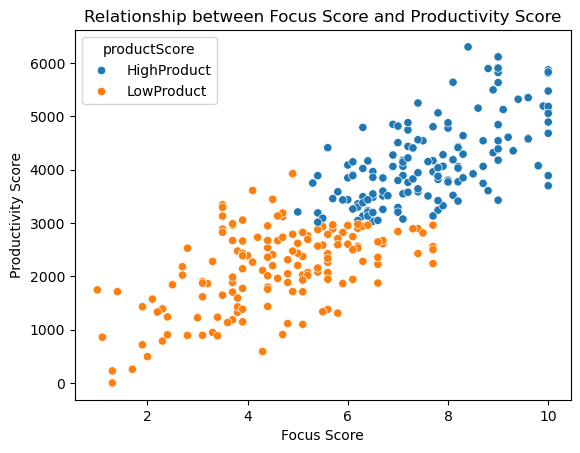

In [34]:
sns.scatterplot(data = df_productivity, x = 'FocusScore', y = 'ProductivityScore', hue = 'productScore')
plt.title("Relationship between Focus Score and Productivity Score")
plt.xlabel("Focus Score")
plt.ylabel("Productivity Score")
plt.show()

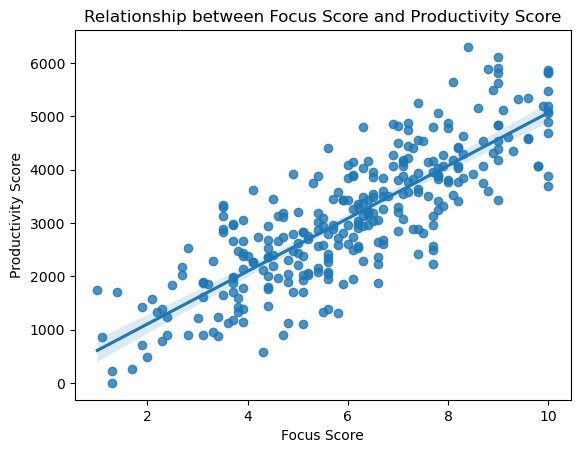

In [35]:
sns.regplot(data = df_productivity, x = 'FocusScore', y = 'ProductivityScore')
plt.title("Relationship between Focus Score and Productivity Score")
plt.xlabel("Focus Score")
plt.ylabel("Productivity Score")
plt.show()

In [38]:
X = sm.add_constant(df_productivity["FocusScore"])
y = df_productivity["ProductivityScore"]
model_focus = sm.OLS(y,X).fit()
model_focus.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      ProductivityScore   R-squared:                       0.678
Model:                            OLS   Adj. R-squared:                  0.677
Method:                 Least Squares   F-statistic:                     626.6
Date:                Mon, 18 May 2026   Prob (F-statistic):           3.02e-75
Time:                        14:26:04   Log-Likelihood:                -2394.3
No. Observations:                 300   AIC:                             4793.
Df Residuals:                     298   BIC:                             4800.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        114.3813    126.657      0.903      0.367    -134.874     363.636
FocusScore   494.9319     19.772     25.032      0.000     456.021     533.843
==============================================================================
Omnibus:                        0.756   Durbin-Watson:                   2.057
Prob(Omnibus):                  0.685   Jarque-Bera (JB):                0.869
Skew:                           0.076   Prob(JB):                        0.648
Kurtosis:                       2.784   Cond. No.                         20.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Looking at the regplot, it can be seen that focus score and productivity score has a linear relationship there. with r-squared = 0.6 and P value is 0, focus score has the strongest linear relationship with productivity score of all.

### RELATIONSHIP BETWEEN DESK LOCATION WITH PRODUCTIVITY SCORE

In [43]:
pd.crosstab(df_productivity['DeskLocation'], df_productivity['ProductivityScore'], normalize = "index") * 100

ProductivityScore,0.00,225.83,255.93,493.18,589.00,714.81,784.88,856.93,883.53,891.46,...,5630.88,5636.85,5809.16,5818.92,5827.95,5868.59,5893.99,5903.01,6112.79,6299.20
DeskLocation,,,,,,,,,,,,,,,,,,,,,
Open Plan,0.970874,0.970874,0.000000,0.970874,0.970874,0.970874,0.000000,0.970874,0.000000,0.970874,...,0.000000,0.970874,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.970874
Private Office,0.000000,0.000000,0.934579,0.000000,0.000000,0.000000,0.934579,0.000000,0.934579,0.000000,...,0.000000,0.000000,0.000000,0.934579,0.934579,0.934579,0.934579,0.934579,0.934579,0.000000
Remote,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.111111,0.000000,1.111111,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


<Axes: >

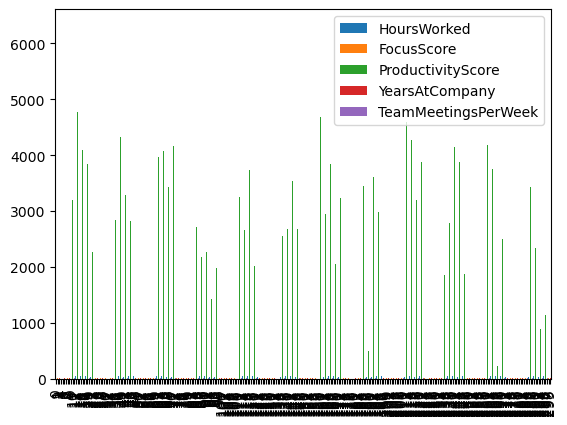

In [42]:

df_productivity.plot(kind = 'bar')